In [2]:
# ============================================================
# EXERCISE 3 - FUNDAMENTALS
# Introduction to Machine Learning Safety
#
# Cell 1: Imports
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")
print()
print("PyTorch version    :", torch.__version__)
print("Torchvision version:", torchvision.__version__)

Libraries imported successfully.

PyTorch version    : 2.5.1+cu121
Torchvision version: 0.20.1+cu121


In [3]:
# ============================================================
# Cell 2: GPU / CUDA verification
# ============================================================

print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. Stop here and fix the GPU environment."
    )

DEVICE = torch.device("cuda")

print()
print("GPU detected successfully!")
print("GPU name     :", torch.cuda.get_device_name(0))
print("CUDA version :", torch.version.cuda)

gpu_properties = torch.cuda.get_device_properties(0)

print(
    "GPU memory   :",
    round(gpu_properties.total_memory / (1024 ** 3), 2),
    "GB"
)

print()
print("Selected device:", DEVICE)

CUDA available: True

GPU detected successfully!
GPU name     : NVIDIA GeForce RTX 3070 Ti Laptop GPU
CUDA version : 12.1
GPU memory   : 8.0 GB

Selected device: cuda


In [4]:
# ============================================================
# Cell 3: Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Reproducible CUDA behaviour
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)
print("Reproducibility configured.")

Random seed: 42
Reproducibility configured.


In [5]:
# ============================================================
# Cell 4: Dataset paths
# ============================================================

BASE_PATH = Path(r"E:\ML_Safety")

TRAIN_DIR = BASE_PATH / "train"
VAL_DIR = BASE_PATH / "validation"
TEST_DIR = BASE_PATH / "test"

FOG_DIR = BASE_PATH / "test-fog"
NIGHT_DIR = BASE_PATH / "test-night"
TOWN_DIR = BASE_PATH / "test-town-01"

TRAIN_IMAGE_DIR = TRAIN_DIR / "rgb-front"
VAL_IMAGE_DIR = VAL_DIR / "rgb-front"
TEST_IMAGE_DIR = TEST_DIR / "rgb-front"

print("Base dataset :", BASE_PATH)
print()
print("Train        :", TRAIN_DIR)
print("Validation   :", VAL_DIR)
print("Test         :", TEST_DIR)
print("Test-fog     :", FOG_DIR)
print("Test-night   :", NIGHT_DIR)
print("Test-town-01 :", TOWN_DIR)

Base dataset : E:\ML_Safety

Train        : E:\ML_Safety\train
Validation   : E:\ML_Safety\validation
Test         : E:\ML_Safety\test
Test-fog     : E:\ML_Safety\test-fog
Test-night   : E:\ML_Safety\test-night
Test-town-01 : E:\ML_Safety\test-town-01


In [6]:
# ============================================================
# Cell 5: Verify dataset structure
# ============================================================

paths_to_check = {
    "Base dataset": BASE_PATH,

    "Train directory": TRAIN_DIR,
    "Train images": TRAIN_IMAGE_DIR,

    "Validation directory": VAL_DIR,
    "Validation images": VAL_IMAGE_DIR,

    "Test directory": TEST_DIR,
    "Test images": TEST_IMAGE_DIR,

    "Fog directory": FOG_DIR,
    "Night directory": NIGHT_DIR,
    "Town directory": TOWN_DIR,
}

print("DATASET STRUCTURE CHECK")
print("=" * 65)

all_found = True

for name, path in paths_to_check.items():

    if path.exists():
        print(f"{name:<30}: FOUND")
    else:
        print(f"{name:<30}: NOT FOUND")
        all_found = False

print("=" * 65)

if all_found:
    print("All required directories were found.")
else:
    print("WARNING: One or more paths are missing.")

DATASET STRUCTURE CHECK
Base dataset                  : FOUND
Train directory               : FOUND
Train images                  : FOUND
Validation directory          : FOUND
Validation images             : FOUND
Test directory                : FOUND
Test images                   : FOUND
Fog directory                 : FOUND
Night directory               : FOUND
Town directory                : FOUND
All required directories were found.


In [7]:
# ============================================================
# Cell 6: Locate label files
# ============================================================

def find_label_files(folder):

    folder = Path(folder)

    candidates = [
        folder / "labels.csv",
        folder / "labels",
        folder / "labels.feather",
        folder / "labels.parquet"
    ]

    return [file for file in candidates if file.exists()]


for name, folder in [
    ("TRAIN", TRAIN_DIR),
    ("VALIDATION", VAL_DIR),
    ("TEST", TEST_DIR)
]:

    print(f"\n{name}")
    print("-" * 50)

    files = find_label_files(folder)

    if files:
        for file in files:
            print("FOUND:", file)
    else:
        print("No label file found.")


TRAIN
--------------------------------------------------
FOUND: E:\ML_Safety\train\labels.csv
FOUND: E:\ML_Safety\train\labels.feather

VALIDATION
--------------------------------------------------
FOUND: E:\ML_Safety\validation\labels.csv
FOUND: E:\ML_Safety\validation\labels.feather

TEST
--------------------------------------------------
FOUND: E:\ML_Safety\test\labels.csv
FOUND: E:\ML_Safety\test\labels.feather


In [8]:
# ============================================================
# Cell 7: Load labels
# ============================================================

def load_labels(folder):

    folder = Path(folder)

    feather_file = folder / "labels.feather"

    if not feather_file.exists():
        raise FileNotFoundError(
            f"Could not find {feather_file}"
        )

    df = pd.read_feather(feather_file)

    print(f"Loaded: {feather_file}")
    print("Shape:", df.shape)

    return df


train_df = load_labels(TRAIN_DIR)
val_df = load_labels(VAL_DIR)
test_df = load_labels(TEST_DIR)

print()
print("Dataset sizes")
print("=" * 50)
print("Training   :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)

Loaded: E:\ML_Safety\train\labels.feather
Shape: (7200, 7)
Loaded: E:\ML_Safety\validation\labels.feather
Shape: (3600, 7)
Loaded: E:\ML_Safety\test\labels.feather
Shape: (3600, 7)

Dataset sizes
Training   : (7200, 7)
Validation : (3600, 7)
Test       : (3600, 7)


In [9]:
# ============================================================
# Cell 8: Inspect label columns and examples
# ============================================================

print("TRAINING COLUMNS")
print("=" * 60)

print(train_df.columns.tolist())

print()
print("VALIDATION COLUMNS")
print("=" * 60)

print(val_df.columns.tolist())

print()
print("TEST COLUMNS")
print("=" * 60)

print(test_df.columns.tolist())

print()
print("FIRST 10 TRAINING ROWS")
print("=" * 60)

display(train_df.head(10))

TRAINING COLUMNS
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

VALIDATION COLUMNS
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

TEST COLUMNS
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

FIRST 10 TRAINING ROWS


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,000000,False,False,True,0,0,85
1,000010,False,True,True,14,301,1138
2,000020,True,True,True,99,196,517
3,000030,True,True,True,99,181,530
4,000040,True,True,True,101,169,538
5,000050,True,True,True,101,160,538
6,000060,True,True,True,115,149,572
7,000070,True,True,True,115,160,582
8,000080,True,True,True,118,473,588
9,000090,True,True,True,118,407,580


In [10]:
# ============================================================
# Cell 9: Count RGB images
# Exercise 3.4 - Dataset size
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


def get_image_files(image_dir):
    image_dir = Path(image_dir)

    files = [
        file
        for file in image_dir.iterdir()
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    return sorted(files)


train_images = get_image_files(TRAIN_IMAGE_DIR)
val_images = get_image_files(VAL_IMAGE_DIR)
test_images = get_image_files(TEST_IMAGE_DIR)

print("IMAGE COUNTS")
print("=" * 55)

print("Training images   :", len(train_images))
print("Validation images :", len(val_images))
print("Test images       :", len(test_images))

print()
print("Example training image files:")
for file in train_images[:10]:
    print(file.name)

IMAGE COUNTS
Training images   : 7200
Validation images : 3600
Test images       : 3600

Example training image files:
000000.jpg
000010.jpg
000020.jpg
000030.jpg
000040.jpg
000050.jpg
000060.jpg
000070.jpg
000080.jpg
000090.jpg


In [11]:
# ============================================================
# Cell 10: Verify label-to-image correspondence
# ============================================================

def normalize_frame(value):
    """
    Convert frame identifiers to a consistent string representation.
    """
    return str(value).strip().replace(".0", "").zfill(6)


train_image_stems = {
    file.stem
    for file in train_images
}

val_image_stems = {
    file.stem
    for file in val_images
}

test_image_stems = {
    file.stem
    for file in test_images
}


train_label_frames = {
    normalize_frame(value)
    for value in train_df["frame"]
}

val_label_frames = {
    normalize_frame(value)
    for value in val_df["frame"]
}

test_label_frames = {
    normalize_frame(value)
    for value in test_df["frame"]
}


print("LABEL ↔ IMAGE CHECK")
print("=" * 60)

print(
    "Training labels:",
    len(train_label_frames),
    "| Training images:",
    len(train_image_stems)
)

print(
    "Validation labels:",
    len(val_label_frames),
    "| Validation images:",
    len(val_image_stems)
)

print(
    "Test labels:",
    len(test_label_frames),
    "| Test images:",
    len(test_image_stems)
)

print()

print(
    "Training labels without images:",
    len(train_label_frames - train_image_stems)
)

print(
    "Training images without labels:",
    len(train_image_stems - train_label_frames)
)

print(
    "Validation labels without images:",
    len(val_label_frames - val_image_stems)
)

print(
    "Validation images without labels:",
    len(val_image_stems - val_label_frames)
)

print(
    "Test labels without images:",
    len(test_label_frames - test_image_stems)
)

print(
    "Test images without labels:",
    len(test_image_stems - test_label_frames)
)

LABEL ↔ IMAGE CHECK
Training labels: 7200 | Training images: 7200
Validation labels: 3600 | Validation images: 3600
Test labels: 3600 | Test images: 3600

Training labels without images: 0
Training images without labels: 0
Validation labels without images: 0
Validation images without labels: 0
Test labels without images: 0
Test images without labels: 0


In [12]:
# ============================================================
# Cell 11: Class distributions
# Exercise 3.4
# ============================================================

TARGET_COLUMNS = {
    "Traffic Light": "has_traffic_light",
    "Pedestrian": "has_pedestrian",
    "Vehicle": "has_vehicle"
}


def class_distribution(df, column):

    counts = df[column].value_counts().sort_index()

    total = len(df)

    result = pd.DataFrame({
        "Count": counts,
        "Percentage": (counts / total * 100).round(2)
    })

    return result


print("TRAINING SET CLASS DISTRIBUTIONS")
print("=" * 65)

for name, column in TARGET_COLUMNS.items():

    print(f"\n{name}")
    print("-" * 40)

    print(
        class_distribution(
            train_df,
            column
        )
    )

TRAINING SET CLASS DISTRIBUTIONS

Traffic Light
----------------------------------------
                   Count  Percentage
has_traffic_light                   
False               1924       26.72
True                5276       73.28

Pedestrian
----------------------------------------
                Count  Percentage
has_pedestrian                   
False            5482       76.14
True             1718       23.86

Vehicle
----------------------------------------
             Count  Percentage
has_vehicle                   
False         1742       24.19
True          5458       75.81


In [13]:
# ============================================================
# Cell 12: Distribution across all splits
# ============================================================

distribution_rows = []

datasets = {
    "Training": train_df,
    "Validation": val_df,
    "Test": test_df
}

for split_name, df in datasets.items():

    for target_name, column in TARGET_COLUMNS.items():

        positive = int(df[column].sum())
        total = len(df)
        negative = total - positive

        distribution_rows.append({
            "Split": split_name,
            "Target": target_name,
            "Negative": negative,
            "Positive": positive,
            "Positive %": round(positive / total * 100, 2),
            "Negative %": round(negative / total * 100, 2)
        })

distribution_df = pd.DataFrame(distribution_rows)

display(distribution_df)

,Split,Target,Negative,Positive,Positive %,Negative %
0,Training,Traffic Light,1924,5276,73.28,26.72
1,Training,Pedestrian,5482,1718,23.86,76.14
2,Training,Vehicle,1742,5458,75.81,24.19
3,Validation,Traffic Light,887,2713,75.36,24.64
4,Validation,Pedestrian,2686,914,25.39,74.61
5,Validation,Vehicle,1232,2368,65.78,34.22
6,Test,Traffic Light,1016,2584,71.78,28.22
7,Test,Pedestrian,2894,706,19.61,80.39
8,Test,Vehicle,900,2700,75.00,25.00


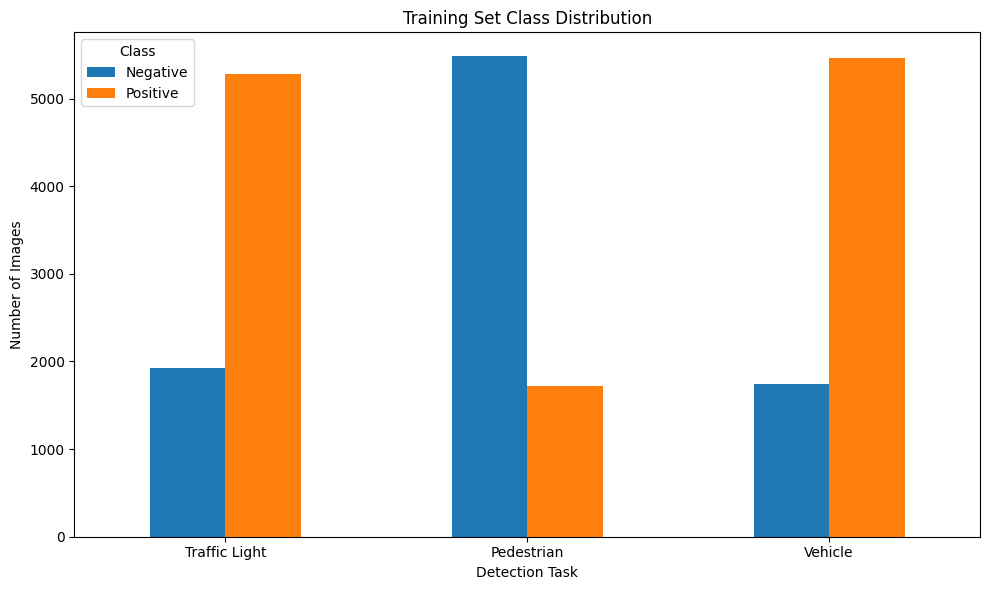

In [14]:
# ============================================================
# Cell 13: Class distribution plot
# ============================================================

plot_data = []

for target_name, column in TARGET_COLUMNS.items():

    counts = train_df[column].value_counts()

    plot_data.append({
        "Target": target_name,
        "Negative": int(counts.get(False, 0)),
        "Positive": int(counts.get(True, 0))
    })


plot_df = pd.DataFrame(plot_data).set_index("Target")

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Training Set Class Distribution")
ax.set_xlabel("Detection Task")
ax.set_ylabel("Number of Images")
ax.tick_params(axis="x", rotation=0)

plt.legend(title="Class")
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Cell 14: Label combinations
# ============================================================

combination_columns = [
    "has_traffic_light",
    "has_pedestrian",
    "has_vehicle"
]

combination_counts = (
    train_df
    .groupby(combination_columns)
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

print("TRAINING LABEL COMBINATIONS")
print("=" * 70)

display(combination_counts)

TRAINING LABEL COMBINATIONS


,has_traffic_light,has_pedestrian,has_vehicle,Count
5,True,False,True,3040
7,True,True,True,1125
1,False,False,True,1063
4,True,False,False,832
0,False,False,False,547
6,True,True,False,279
3,False,True,True,230
2,False,True,False,84


In [16]:
# ============================================================
# Cell 15: Label combination percentages
# ============================================================

combination_counts["Percentage"] = (
    combination_counts["Count"]
    / len(train_df)
    * 100
).round(2)

print("TRAINING LABEL COMBINATIONS WITH PERCENTAGES")
print("=" * 75)

display(combination_counts)

TRAINING LABEL COMBINATIONS WITH PERCENTAGES


,has_traffic_light,has_pedestrian,has_vehicle,Count,Percentage
5,True,False,True,3040,42.22
7,True,True,True,1125,15.62
1,False,False,True,1063,14.76
4,True,False,False,832,11.56
0,False,False,False,547,7.60
6,True,True,False,279,3.88
3,False,True,True,230,3.19
2,False,True,False,84,1.17


In [17]:
# ============================================================
# Cell 16: Match labels to image files
# ============================================================

train_df_plot = train_df.copy()

train_df_plot["frame_str"] = (
    train_df_plot["frame"]
    .apply(normalize_frame)
)

image_lookup = {
    file.stem: file
    for file in train_images
}

train_df_plot["image_path"] = (
    train_df_plot["frame_str"]
    .map(image_lookup)
)

missing_images = train_df_plot["image_path"].isna().sum()

print("IMAGE ↔ LABEL MATCHING")
print("=" * 60)
print("Training records :", len(train_df_plot))
print("Matched images   :", train_df_plot["image_path"].notna().sum())
print("Missing images   :", missing_images)

IMAGE ↔ LABEL MATCHING
Training records : 7200
Matched images   : 7200
Missing images   : 0


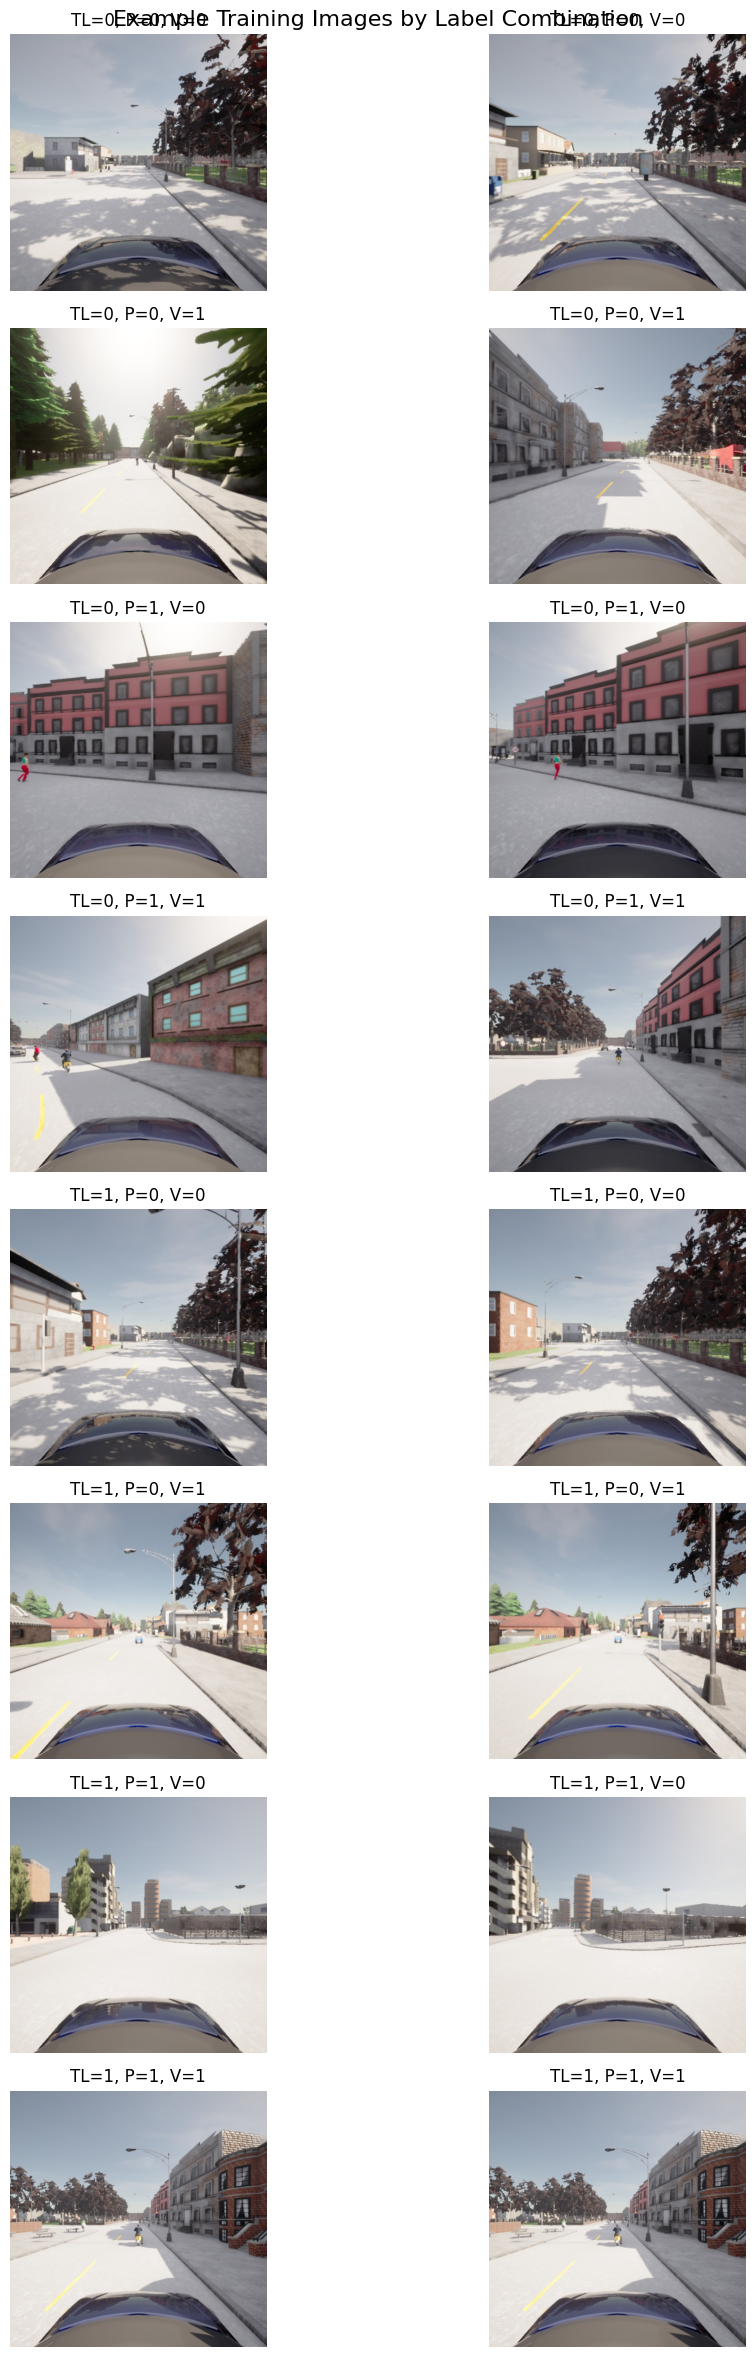

In [18]:
# ============================================================
# Cell 17: Display example images for label combinations
# ============================================================

examples_per_combination = 2

groups = list(
    train_df_plot.groupby(combination_columns)
)

fig, axes = plt.subplots(
    len(groups),
    examples_per_combination,
    figsize=(12, max(4, len(groups) * 3))
)

axes = np.atleast_2d(axes)

for row_idx, (combination, group) in enumerate(groups):

    selected = (
        group
        .dropna(subset=["image_path"])
        .head(examples_per_combination)
    )

    for col_idx in range(examples_per_combination):

        ax = axes[row_idx, col_idx]
        ax.axis("off")

        if col_idx < len(selected):

            row = selected.iloc[col_idx]

            image = Image.open(
                row["image_path"]
            ).convert("RGB")

            ax.imshow(image)

            traffic = int(row["has_traffic_light"])
            pedestrian = int(row["has_pedestrian"])
            vehicle = int(row["has_vehicle"])

            ax.set_title(
                f"TL={traffic}, P={pedestrian}, V={vehicle}"
            )

plt.suptitle(
    "Example Training Images by Label Combination",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# Cell 18: Exercise 3.4 summary
# ============================================================

print("=" * 75)
print("EXERCISE 3.4 - DATASET EXPLORATION SUMMARY")
print("=" * 75)

print("\nDATASET SIZE")
print("-" * 50)

print(f"Training images   : {len(train_df)}")
print(f"Validation images : {len(val_df)}")
print(f"Test images       : {len(test_df)}")

print("\nCLASS DISTRIBUTIONS - TRAINING")
print("-" * 50)

for name, column in TARGET_COLUMNS.items():

    positive = int(train_df[column].sum())
    negative = len(train_df) - positive

    positive_pct = positive / len(train_df) * 100
    negative_pct = negative / len(train_df) * 100

    print(
        f"{name:15s}: "
        f"Negative = {negative:4d} ({negative_pct:5.2f}%), "
        f"Positive = {positive:4d} ({positive_pct:5.2f}%)"
    )

print("\nLABEL COMBINATIONS")
print("-" * 50)

print(
    f"Observed combinations: "
    f"{len(combination_counts)} / 8"
)

print(
    f"Most common combination: "
    f"{combination_counts.iloc[0]['Count']} images "
    f"({combination_counts.iloc[0]['Percentage']:.2f}%)"
)

print(
    f"Least common combination: "
    f"{combination_counts.iloc[-1]['Count']} images "
    f"({combination_counts.iloc[-1]['Percentage']:.2f}%)"
)

print("\nExercise 3.4 completed.")

EXERCISE 3.4 - DATASET EXPLORATION SUMMARY

DATASET SIZE
--------------------------------------------------
Training images   : 7200
Validation images : 3600
Test images       : 3600

CLASS DISTRIBUTIONS - TRAINING
--------------------------------------------------
Traffic Light  : Negative = 1924 (26.72%), Positive = 5276 (73.28%)
Pedestrian     : Negative = 5482 (76.14%), Positive = 1718 (23.86%)
Vehicle        : Negative = 1742 (24.19%), Positive = 5458 (75.81%)

LABEL COMBINATIONS
--------------------------------------------------
Observed combinations: 8 / 8
Most common combination: 3040 images (42.22%)
Least common combination: 84 images (1.17%)

Exercise 3.4 completed.


In [20]:
# ============================================================
# Exercise 3.5
# Cell 19: Training configuration
# ============================================================

NUM_CLASSES = 2

BATCH_SIZE = 64
NUM_EPOCHS = 10

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

NUM_WORKERS = 0

MODEL_DIR = BASE_PATH / "model_outputs"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("TRAINING CONFIGURATION")
print("=" * 60)

print("Device        :", DEVICE)
print("Batch size    :", BATCH_SIZE)
print("Epochs        :", NUM_EPOCHS)
print("Learning rate :", LEARNING_RATE)
print("Weight decay  :", WEIGHT_DECAY)
print("Workers       :", NUM_WORKERS)
print("Model folder  :", MODEL_DIR)

if torch.cuda.is_available():
    print()
    print("GPU           :", torch.cuda.get_device_name(0))

TRAINING CONFIGURATION
Device        : cuda
Batch size    : 64
Epochs        : 10
Learning rate : 0.0001
Weight decay  : 0.0001
Workers       : 0
Model folder  : E:\ML_Safety\model_outputs

GPU           : NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [21]:
# ============================================================
# Cell 20: Image transformations
# ============================================================

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


print("Training transform:")
print(train_transform)

print()
print("Evaluation transform:")
print(eval_transform)

Training transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Evaluation transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [22]:
# ============================================================
# Cell 21: CARLA Dataset class
# ============================================================

class CARLADetectionDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_lookup,
        target_column,
        transform=None
    ):

        self.df = dataframe.reset_index(drop=True).copy()
        self.image_lookup = image_lookup
        self.target_column = target_column
        self.transform = transform

        # Convert frame IDs to image filenames
        self.df["frame_str"] = (
            self.df["frame"]
            .apply(normalize_frame)
        )

        # Verify every image exists
        self.df["image_path"] = (
            self.df["frame_str"]
            .map(self.image_lookup)
        )

        missing = self.df["image_path"].isna().sum()

        if missing > 0:
            raise RuntimeError(
                f"{missing} images are missing for "
                f"target '{target_column}'."
            )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = row["image_path"]

        image = Image.open(
            image_path
        ).convert("RGB")

        label = int(
            bool(row[self.target_column])
        )

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(
            label,
            dtype=torch.long
        )

In [23]:
# ============================================================
# Cell 22: Image lookups
# ============================================================

train_image_lookup = {
    file.stem: file
    for file in train_images
}

val_image_lookup = {
    file.stem: file
    for file in val_images
}

test_image_lookup = {
    file.stem: file
    for file in test_images
}


print("Image lookup sizes")
print("=" * 50)

print("Training   :", len(train_image_lookup))
print("Validation :", len(val_image_lookup))
print("Test       :", len(test_image_lookup))

Image lookup sizes
Training   : 7200
Validation : 3600
Test       : 3600


In [24]:
# ============================================================
# Cell 23: Create datasets for all three detection tasks
# ============================================================

ped_train_dataset = CARLADetectionDataset(
    train_df,
    train_image_lookup,
    "has_pedestrian",
    train_transform
)

ped_val_dataset = CARLADetectionDataset(
    val_df,
    val_image_lookup,
    "has_pedestrian",
    eval_transform
)


tl_train_dataset = CARLADetectionDataset(
    train_df,
    train_image_lookup,
    "has_traffic_light",
    train_transform
)

tl_val_dataset = CARLADetectionDataset(
    val_df,
    val_image_lookup,
    "has_traffic_light",
    eval_transform
)


vehicle_train_dataset = CARLADetectionDataset(
    train_df,
    train_image_lookup,
    "has_vehicle",
    train_transform
)

vehicle_val_dataset = CARLADetectionDataset(
    val_df,
    val_image_lookup,
    "has_vehicle",
    eval_transform
)


print("DATASETS CREATED")
print("=" * 60)

print("Pedestrian training :", len(ped_train_dataset))
print("Pedestrian validation:", len(ped_val_dataset))

print("Traffic-light training :", len(tl_train_dataset))
print("Traffic-light validation:", len(tl_val_dataset))

print("Vehicle training :", len(vehicle_train_dataset))
print("Vehicle validation:", len(vehicle_val_dataset))

DATASETS CREATED
Pedestrian training : 7200
Pedestrian validation: 3600
Traffic-light training : 7200
Traffic-light validation: 3600
Vehicle training : 7200
Vehicle validation: 3600


In [25]:
# ============================================================
# Cell 24: DataLoaders
# ============================================================

def create_dataloader(
    dataset,
    shuffle
):

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )


ped_train_loader = create_dataloader(
    ped_train_dataset,
    shuffle=True
)

ped_val_loader = create_dataloader(
    ped_val_dataset,
    shuffle=False
)


tl_train_loader = create_dataloader(
    tl_train_dataset,
    shuffle=True
)

tl_val_loader = create_dataloader(
    tl_val_dataset,
    shuffle=False
)


vehicle_train_loader = create_dataloader(
    vehicle_train_dataset,
    shuffle=True
)

vehicle_val_loader = create_dataloader(
    vehicle_val_dataset,
    shuffle=False
)


print("DATALOADERS CREATED")
print("=" * 60)

print(
    "Pedestrian:",
    len(ped_train_loader),
    "training batches |",
    len(ped_val_loader),
    "validation batches"
)

print(
    "Traffic light:",
    len(tl_train_loader),
    "training batches |",
    len(tl_val_loader),
    "validation batches"
)

print(
    "Vehicle:",
    len(vehicle_train_loader),
    "training batches |",
    len(vehicle_val_loader),
    "validation batches"
)

DATALOADERS CREATED
Pedestrian: 113 training batches | 57 validation batches
Traffic light: 113 training batches | 57 validation batches
Vehicle: 113 training batches | 57 validation batches


In [26]:
# ============================================================
# Cell 25: Test one training batch
# ============================================================

images, labels = next(iter(ped_train_loader))

print("Batch test")
print("=" * 50)

print("Image tensor shape :", images.shape)
print("Label tensor shape :", labels.shape)
print("Label dtype        :", labels.dtype)

print()
print("Before GPU:")
print("Image device :", images.device)
print("Label device :", labels.device)


images = images.to(DEVICE, non_blocking=True)
labels = labels.to(DEVICE, non_blocking=True)


print()
print("After GPU:")
print("Image device :", images.device)
print("Label device :", labels.device)

print()
print("Unique labels:", torch.unique(labels).tolist())

Batch test
Image tensor shape : torch.Size([64, 3, 224, 224])
Label tensor shape : torch.Size([64])
Label dtype        : torch.int64

Before GPU:
Image device : cpu
Label device : cpu

After GPU:
Image device : cuda:0
Label device : cuda:0

Unique labels: [0, 1]


In [27]:
# ============================================================
# Cell 26: ResNet-18 model factory
# ============================================================

def create_resnet18():

    # Load pretrained ImageNet weights
    model = resnet18(
        weights=ResNet18_Weights.DEFAULT
    )

    # Get number of input features to final layer
    num_features = model.fc.in_features

    # Replace final classification layer
    model.fc = nn.Linear(
        num_features,
        NUM_CLASSES
    )

    return model

In [28]:
# ============================================================
# Cell 27: Create three independent models
# ============================================================

ped_model = create_resnet18()
tl_model = create_resnet18()
vehicle_model = create_resnet18()


# Move models to GPU
ped_model = ped_model.to(DEVICE)
tl_model = tl_model.to(DEVICE)
vehicle_model = vehicle_model.to(DEVICE)


print("Three models created and moved to GPU.")
print()
print("Pedestrian model device :", next(ped_model.parameters()).device)
print("Traffic-light model device:", next(tl_model.parameters()).device)
print("Vehicle model device    :", next(vehicle_model.parameters()).device)

Three models created and moved to GPU.

Pedestrian model device : cuda:0
Traffic-light model device: cuda:0
Vehicle model device    : cuda:0


In [29]:
# ============================================================
# Cell 28: Inspect model architecture
# ============================================================

print(ped_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [30]:
# ============================================================
# Cell 29: Count trainable parameters
# ============================================================

def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


print("TRAINABLE PARAMETERS")
print("=" * 60)

print(
    "Pedestrian    :",
    f"{count_parameters(ped_model):,}"
)

print(
    "Traffic Light :",
    f"{count_parameters(tl_model):,}"
)

print(
    "Vehicle       :",
    f"{count_parameters(vehicle_model):,}"
)

TRAINABLE PARAMETERS
Pedestrian    : 11,177,538
Traffic Light : 11,177,538
Vehicle       : 11,177,538


In [31]:
# ============================================================
# Cell 30: Loss functions and optimizers
# ============================================================

criterion_pedestrian = nn.CrossEntropyLoss()

criterion_traffic_light = nn.CrossEntropyLoss()

criterion_vehicle = nn.CrossEntropyLoss()


optimizer_pedestrian = torch.optim.Adam(
    ped_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

optimizer_traffic_light = torch.optim.Adam(
    tl_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

optimizer_vehicle = torch.optim.Adam(
    vehicle_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


print("Loss function : CrossEntropyLoss")
print("Optimizer     : Adam")
print("Learning rate :", LEARNING_RATE)
print("Weight decay  :", WEIGHT_DECAY)

Loss function : CrossEntropyLoss
Optimizer     : Adam
Learning rate : 0.0001
Weight decay  : 0.0001


In [32]:
# ============================================================
# Cell 31: Test forward pass
# ============================================================

images, labels = next(iter(ped_train_loader))

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)


with torch.no_grad():

    outputs = ped_model(images)


print("FORWARD PASS TEST")
print("=" * 60)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)
print("Label shape :", labels.shape)

print()
print("Output device:", outputs.device)
print("Label device :", labels.device)

print()
print("Sample logits:")
print(outputs[:5])

FORWARD PASS TEST
Input shape : torch.Size([64, 3, 224, 224])
Output shape: torch.Size([64, 2])
Label shape : torch.Size([64])

Output device: cuda:0
Label device : cuda:0

Sample logits:
tensor([[-0.2732, -0.0535],
        [-0.4984,  1.0946],
        [-0.1987,  0.7591],
        [-0.1577,  0.4977],
        [ 0.2466,  0.4579]], device='cuda:0')


In [33]:
# ============================================================
# Cell 32: Training and validation functions
# ============================================================

import time
import copy


def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer
):
    """
    Train one complete epoch.
    """

    model.train()

    running_loss = 0.0
    total_samples = 0

    for images, labels in dataloader:

        # Move data to GPU
        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        # Clear previous gradients
        optimizer.zero_grad(
            set_to_none=True
        )

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Accumulate loss
        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

    epoch_loss = (
        running_loss / total_samples
    )

    return epoch_loss


@torch.no_grad()
def validate_one_epoch(
    model,
    dataloader,
    criterion
):
    """
    Evaluate model on validation data.
    """

    model.eval()

    running_loss = 0.0
    total_samples = 0

    for images, labels in dataloader:

        # Move data to GPU
        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        # Forward pass
        outputs = model(images)

        # Validation loss
        loss = criterion(
            outputs,
            labels
        )

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

    epoch_loss = (
        running_loss / total_samples
    )

    return epoch_loss


def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    model_name,
    num_epochs=NUM_EPOCHS
):
    """
    Train a model and save the weights
    corresponding to the best validation loss.
    """

    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_loss = float("inf")

    best_state = copy.deepcopy(
        model.state_dict()
    )

    print()
    print("=" * 75)
    print(f"TRAINING: {model_name}")
    print("=" * 75)

    for epoch in range(num_epochs):

        start_time = time.time()

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss = validate_one_epoch(
            model,
            val_loader,
            criterion
        )

        epoch_time = (
            time.time() - start_time
        )

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        # Save best model state
        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_state = copy.deepcopy(
                model.state_dict()
            )

            print(
                f"Epoch {epoch + 1:02d}/{num_epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Time: {epoch_time:.1f}s | "
                f"BEST"
            )

        else:

            print(
                f"Epoch {epoch + 1:02d}/{num_epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Time: {epoch_time:.1f}s"
            )

    # Restore best validation model
    model.load_state_dict(
        best_state
    )

    # Define model filename
    model_path = (
        MODEL_DIR /
        f"best_{model_name}.pth"
    )

    # Save checkpoint
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "model_name": model_name,
            "best_val_loss": best_val_loss,
            "history": history,
            "num_classes": NUM_CLASSES,
            "input_size": 224,
            "seed": SEED
        },
        model_path
    )

    print()
    print(f"Best validation loss: {best_val_loss:.4f}")
    print(f"Model saved to: {model_path}")

    return history, best_val_loss

In [34]:
# ============================================================
# Cell 33: Train pedestrian classifier
# ============================================================

ped_history, ped_best_val_loss = train_model(
    model=ped_model,
    train_loader=ped_train_loader,
    val_loader=ped_val_loader,
    criterion=criterion_pedestrian,
    optimizer=optimizer_pedestrian,
    model_name="pedestrian",
    num_epochs=NUM_EPOCHS
)


TRAINING: pedestrian
Epoch 01/10 | Train Loss: 0.4591 | Val Loss: 0.6458 | Time: 167.8s | BEST
Epoch 02/10 | Train Loss: 0.2849 | Val Loss: 0.6913 | Time: 57.2s
Epoch 03/10 | Train Loss: 0.1698 | Val Loss: 0.8118 | Time: 62.3s
Epoch 04/10 | Train Loss: 0.1124 | Val Loss: 0.8452 | Time: 64.4s
Epoch 05/10 | Train Loss: 0.0766 | Val Loss: 0.9391 | Time: 58.0s
Epoch 06/10 | Train Loss: 0.0605 | Val Loss: 1.1799 | Time: 58.0s
Epoch 07/10 | Train Loss: 0.0494 | Val Loss: 1.2540 | Time: 58.1s
Epoch 08/10 | Train Loss: 0.0376 | Val Loss: 1.2074 | Time: 58.0s
Epoch 09/10 | Train Loss: 0.0381 | Val Loss: 1.0924 | Time: 58.0s
Epoch 10/10 | Train Loss: 0.0341 | Val Loss: 1.5088 | Time: 57.6s

Best validation loss: 0.6458
Model saved to: E:\ML_Safety\model_outputs\best_pedestrian.pth


In [35]:
# ============================================================
# Cell 34: Train traffic-light classifier
# ============================================================

tl_history, tl_best_val_loss = train_model(
    model=tl_model,
    train_loader=tl_train_loader,
    val_loader=tl_val_loader,
    criterion=criterion_traffic_light,
    optimizer=optimizer_traffic_light,
    model_name="traffic_light",
    num_epochs=NUM_EPOCHS
)


TRAINING: traffic_light
Epoch 01/10 | Train Loss: 0.1492 | Val Loss: 0.0791 | Time: 61.3s | BEST
Epoch 02/10 | Train Loss: 0.0356 | Val Loss: 0.0662 | Time: 56.5s | BEST
Epoch 03/10 | Train Loss: 0.0286 | Val Loss: 0.0582 | Time: 57.5s | BEST
Epoch 04/10 | Train Loss: 0.0133 | Val Loss: 0.0687 | Time: 57.4s
Epoch 05/10 | Train Loss: 0.0074 | Val Loss: 0.0672 | Time: 57.1s
Epoch 06/10 | Train Loss: 0.0102 | Val Loss: 0.0871 | Time: 57.5s
Epoch 07/10 | Train Loss: 0.0155 | Val Loss: 0.0999 | Time: 57.2s
Epoch 08/10 | Train Loss: 0.0197 | Val Loss: 0.0910 | Time: 57.6s
Epoch 09/10 | Train Loss: 0.0111 | Val Loss: 0.0758 | Time: 57.5s
Epoch 10/10 | Train Loss: 0.0076 | Val Loss: 0.0812 | Time: 57.2s

Best validation loss: 0.0582
Model saved to: E:\ML_Safety\model_outputs\best_traffic_light.pth


In [36]:
# ============================================================
# Cell 35: Train vehicle classifier
# ============================================================

vehicle_history, vehicle_best_val_loss = train_model(
    model=vehicle_model,
    train_loader=vehicle_train_loader,
    val_loader=vehicle_val_loader,
    criterion=criterion_vehicle,
    optimizer=optimizer_vehicle,
    model_name="vehicle",
    num_epochs=NUM_EPOCHS
)


TRAINING: vehicle
Epoch 01/10 | Train Loss: 0.3218 | Val Loss: 0.3354 | Time: 71.7s | BEST
Epoch 02/10 | Train Loss: 0.1743 | Val Loss: 0.3274 | Time: 63.2s | BEST
Epoch 03/10 | Train Loss: 0.1334 | Val Loss: 0.3456 | Time: 57.0s
Epoch 04/10 | Train Loss: 0.0911 | Val Loss: 0.3440 | Time: 59.8s
Epoch 05/10 | Train Loss: 0.0700 | Val Loss: 0.3294 | Time: 57.2s
Epoch 06/10 | Train Loss: 0.0549 | Val Loss: 0.3803 | Time: 57.5s
Epoch 07/10 | Train Loss: 0.0590 | Val Loss: 0.4029 | Time: 57.3s
Epoch 08/10 | Train Loss: 0.0391 | Val Loss: 0.4391 | Time: 57.4s
Epoch 09/10 | Train Loss: 0.0388 | Val Loss: 0.4697 | Time: 57.8s
Epoch 10/10 | Train Loss: 0.0366 | Val Loss: 0.4473 | Time: 57.9s

Best validation loss: 0.3274
Model saved to: E:\ML_Safety\model_outputs\best_vehicle.pth


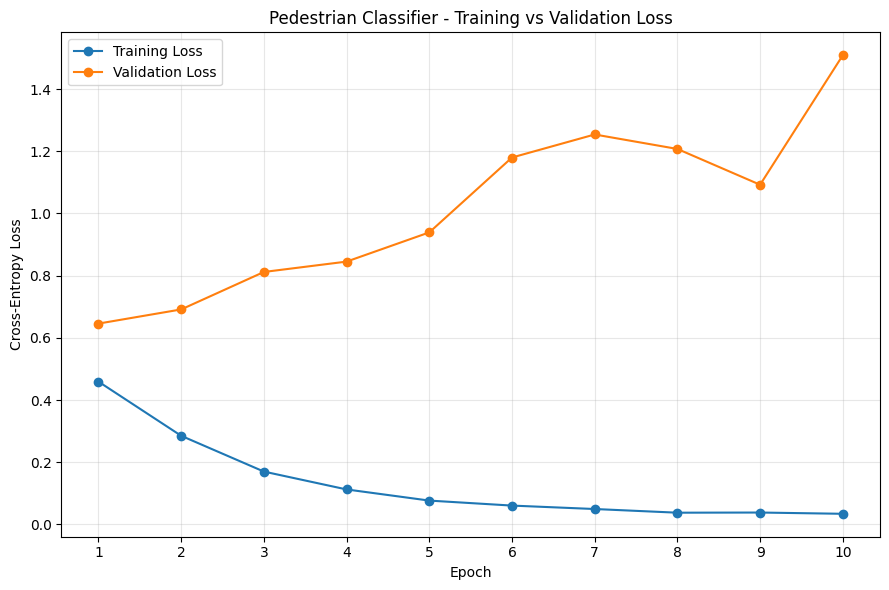

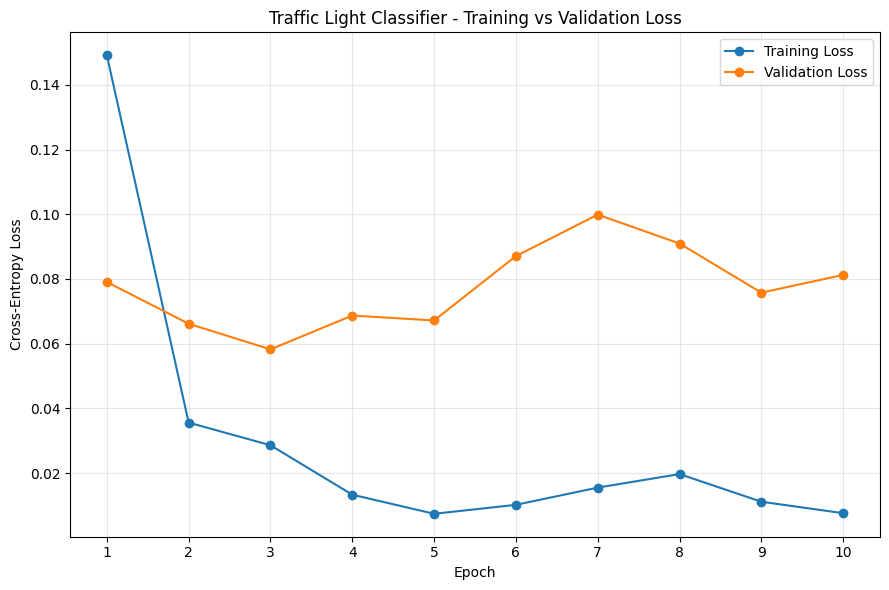

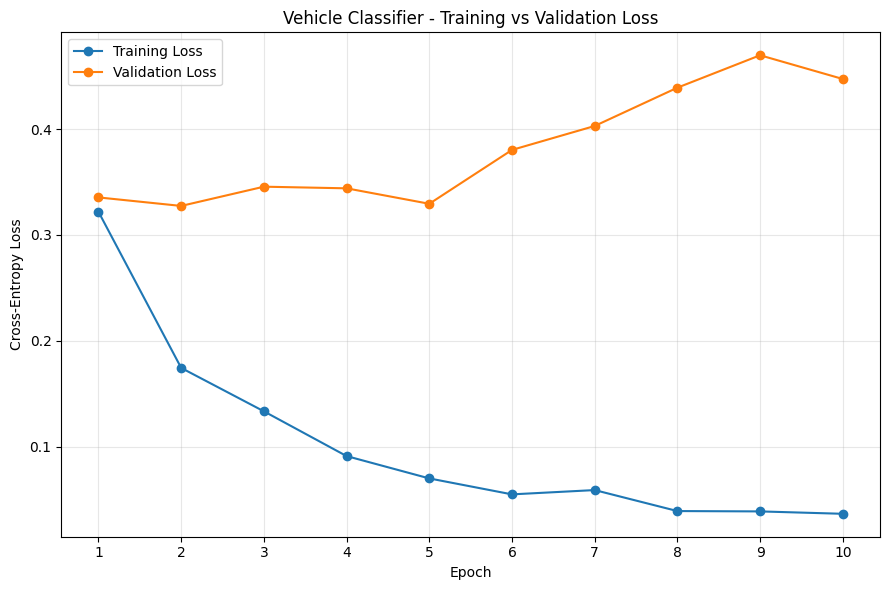

In [37]:
# ============================================================
# Cell 36: Training and validation loss curves
# Exercise 3.5.2
# ============================================================

histories = {
    "Pedestrian": ped_history,
    "Traffic Light": tl_history,
    "Vehicle": vehicle_history
}


for model_name, history in histories.items():

    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")

    plt.title(
        f"{model_name} Classifier - Training vs Validation Loss"
    )

    plt.xticks(
        list(epochs)
    )

    plt.legend()

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.show()

In [38]:
# ============================================================
# Cell 37: Best epoch analysis
# ============================================================

print("BEST VALIDATION EPOCH")
print("=" * 70)

best_epoch_summary = []

for model_name, history in histories.items():

    val_losses = history["val_loss"]

    best_index = int(
        np.argmin(val_losses)
    )

    best_epoch = best_index + 1

    best_val_loss = val_losses[
        best_index
    ]

    train_loss_at_best = history[
        "train_loss"
    ][best_index]

    final_train_loss = history[
        "train_loss"
    ][-1]

    final_val_loss = history[
        "val_loss"
    ][-1]

    best_epoch_summary.append({
        "Model": model_name,
        "Best Epoch": best_epoch,
        "Train Loss at Best": round(
            train_loss_at_best, 4
        ),
        "Best Validation Loss": round(
            best_val_loss, 4
        ),
        "Final Train Loss": round(
            final_train_loss, 4
        ),
        "Final Validation Loss": round(
            final_val_loss, 4
        )
    })


best_epoch_df = pd.DataFrame(
    best_epoch_summary
)

display(best_epoch_df)

BEST VALIDATION EPOCH


,Model,Best Epoch,Train Loss at Best,Best Validation Loss,Final Train Loss,Final Validation Loss
0,Pedestrian,1,0.4591,0.6458,0.0341,1.5088
1,Traffic Light,3,0.0286,0.0582,0.0076,0.0812
2,Vehicle,2,0.1743,0.3274,0.0366,0.4473


In [39]:
# ============================================================
# Cell 38: Verify saved model files
# ============================================================

model_files = {
    "Pedestrian": MODEL_DIR / "best_pedestrian.pth",
    "Traffic Light": MODEL_DIR / "best_traffic_light.pth",
    "Vehicle": MODEL_DIR / "best_vehicle.pth"
}


print("SAVED MODEL CHECK")
print("=" * 70)

for name, path in model_files.items():

    if path.exists():

        size_mb = (
            path.stat().st_size
            / (1024 ** 2)
        )

        print(
            f"{name:15s}: FOUND | "
            f"{size_mb:.2f} MB | "
            f"{path}"
        )

    else:

        print(
            f"{name:15s}: NOT FOUND"
        )

SAVED MODEL CHECK
Pedestrian     : FOUND | 42.72 MB | E:\ML_Safety\model_outputs\best_pedestrian.pth
Traffic Light  : FOUND | 42.72 MB | E:\ML_Safety\model_outputs\best_traffic_light.pth
Vehicle        : FOUND | 42.72 MB | E:\ML_Safety\model_outputs\best_vehicle.pth


In [40]:
# ============================================================
# Cell 39: Exercise 3.5 summary
# ============================================================

print("=" * 75)
print("EXERCISE 3.5 - TRAINING SUMMARY")
print("=" * 75)

print("\nMODEL ARCHITECTURE")
print("-" * 50)
print("Backbone       : Pretrained ResNet-18")
print("Output classes : 2")
print("Loss           : CrossEntropyLoss")
print("Optimizer      : Adam")
print("Learning rate  :", LEARNING_RATE)
print("Weight decay   :", WEIGHT_DECAY)
print("Batch size     :", BATCH_SIZE)
print("Epochs         :", NUM_EPOCHS)
print("Device         :", torch.cuda.get_device_name(0))

print("\nTRAINING RESULTS")
print("-" * 50)

for row in best_epoch_summary:

    print(
        f"{row['Model']:15s} | "
        f"Best epoch: {row['Best Epoch']} | "
        f"Best val loss: {row['Best Validation Loss']:.4f}"
    )

print("\nSaved models:")
for name, path in model_files.items():
    print(f"  {name}: {path}")

print("\nExercise 3.5 completed.")

EXERCISE 3.5 - TRAINING SUMMARY

MODEL ARCHITECTURE
--------------------------------------------------
Backbone       : Pretrained ResNet-18
Output classes : 2
Loss           : CrossEntropyLoss
Optimizer      : Adam
Learning rate  : 0.0001
Weight decay   : 0.0001
Batch size     : 64
Epochs         : 10
Device         : NVIDIA GeForce RTX 3070 Ti Laptop GPU

TRAINING RESULTS
--------------------------------------------------
Pedestrian      | Best epoch: 1 | Best val loss: 0.6458
Traffic Light   | Best epoch: 3 | Best val loss: 0.0582
Vehicle         | Best epoch: 2 | Best val loss: 0.3274

Saved models:
  Pedestrian: E:\ML_Safety\model_outputs\best_pedestrian.pth
  Traffic Light: E:\ML_Safety\model_outputs\best_traffic_light.pth
  Vehicle: E:\ML_Safety\model_outputs\best_vehicle.pth

Exercise 3.5 completed.


In [41]:
# ============================================================
# Cell 40: Create test datasets
# Exercise 3.6
# ============================================================

ped_test_dataset = CARLADetectionDataset(
    test_df,
    test_image_lookup,
    "has_pedestrian",
    eval_transform
)

tl_test_dataset = CARLADetectionDataset(
    test_df,
    test_image_lookup,
    "has_traffic_light",
    eval_transform
)

vehicle_test_dataset = CARLADetectionDataset(
    test_df,
    test_image_lookup,
    "has_vehicle",
    eval_transform
)


print("TEST DATASETS")
print("=" * 60)

print(
    "Pedestrian test images    :",
    len(ped_test_dataset)
)

print(
    "Traffic-light test images:",
    len(tl_test_dataset)
)

print(
    "Vehicle test images       :",
    len(vehicle_test_dataset)
)

TEST DATASETS
Pedestrian test images    : 3600
Traffic-light test images: 3600
Vehicle test images       : 3600


In [42]:
# ============================================================
# Cell 41: Test DataLoaders
# ============================================================

ped_test_loader = create_dataloader(
    ped_test_dataset,
    shuffle=False
)

tl_test_loader = create_dataloader(
    tl_test_dataset,
    shuffle=False
)

vehicle_test_loader = create_dataloader(
    vehicle_test_dataset,
    shuffle=False
)


print("TEST DATALOADERS")
print("=" * 60)

print(
    "Pedestrian    :",
    len(ped_test_loader),
    "batches"
)

print(
    "Traffic Light :",
    len(tl_test_loader),
    "batches"
)

print(
    "Vehicle        :",
    len(vehicle_test_loader),
    "batches"
)

TEST DATALOADERS
Pedestrian    : 57 batches
Traffic Light : 57 batches
Vehicle        : 57 batches


In [43]:
# ============================================================
# Cell 42: Model evaluation function
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


@torch.no_grad()
def evaluate_model(
    model,
    dataloader
):

    model.eval()

    all_predictions = []
    all_labels = []
    all_probabilities = []

    for images, labels in dataloader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        # Forward pass
        outputs = model(images)

        # Convert logits to probabilities
        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        # Predicted class
        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities[:, 1]
            .cpu()
            .numpy()
        )

    all_labels = np.array(
        all_labels
    )

    all_predictions = np.array(
        all_predictions
    )

    all_probabilities = np.array(
        all_probabilities
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    cm = confusion_matrix(
        all_labels,
        all_predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "labels": all_labels,
        "predictions": all_predictions,
        "probabilities": all_probabilities
    }

In [44]:
# ============================================================
# Cell 43: Evaluate pedestrian model
# ============================================================

ped_test_results = evaluate_model(
    ped_model,
    ped_test_loader
)


print("PEDESTRIAN TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy  : "
    f"{ped_test_results['accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{ped_test_results['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{ped_test_results['recall']:.4f}"
)

print(
    f"F1 Score  : "
    f"{ped_test_results['f1']:.4f}"
)

print("\nConfusion Matrix:")
print(
    ped_test_results["confusion_matrix"]
)

PEDESTRIAN TEST RESULTS
Accuracy  : 0.7914
Precision : 0.3834
Recall    : 0.1048
F1 Score  : 0.1646

Confusion Matrix:
[[2775  119]
 [ 632   74]]


In [45]:
# ============================================================
# Cell 44: Evaluate traffic-light model
# ============================================================

tl_test_results = evaluate_model(
    tl_model,
    tl_test_loader
)


print("TRAFFIC-LIGHT TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy  : "
    f"{tl_test_results['accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{tl_test_results['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{tl_test_results['recall']:.4f}"
)

print(
    f"F1 Score  : "
    f"{tl_test_results['f1']:.4f}"
)

print("\nConfusion Matrix:")
print(
    tl_test_results["confusion_matrix"]
)

TRAFFIC-LIGHT TEST RESULTS
Accuracy  : 0.9375
Precision : 0.9380
Recall    : 0.9776
F1 Score  : 0.9574

Confusion Matrix:
[[ 849  167]
 [  58 2526]]


In [46]:
# ============================================================
# Cell 45: Evaluate vehicle model
# ============================================================

vehicle_test_results = evaluate_model(
    vehicle_model,
    vehicle_test_loader
)


print("VEHICLE TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy  : "
    f"{vehicle_test_results['accuracy']:.4f}"
)

print(
    f"Precision : "
    f"{vehicle_test_results['precision']:.4f}"
)

print(
    f"Recall    : "
    f"{vehicle_test_results['recall']:.4f}"
)

print(
    f"F1 Score  : "
    f"{vehicle_test_results['f1']:.4f}"
)

print("\nConfusion Matrix:")
print(
    vehicle_test_results["confusion_matrix"]
)

VEHICLE TEST RESULTS
Accuracy  : 0.8842
Precision : 0.9152
Recall    : 0.9319
F1 Score  : 0.9235

Confusion Matrix:
[[ 667  233]
 [ 184 2516]]


In [47]:
# ============================================================
# Cell 46: Combined test-set evaluation
# Exercise 3.6
# ============================================================

test_results = {
    "Pedestrian": ped_test_results,
    "Traffic Light": tl_test_results,
    "Vehicle": vehicle_test_results
}


comparison_rows = []

for model_name, results in test_results.items():

    comparison_rows.append({
        "Model": model_name,
        "Accuracy": results["accuracy"],
        "Precision": results["precision"],
        "Recall": results["recall"],
        "F1": results["f1"]
    })


comparison_df = pd.DataFrame(
    comparison_rows
)

# Convert to percentages for easier reading
comparison_display = comparison_df.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]:
    comparison_display[column] = (
        comparison_display[column] * 100
    ).round(2)


print("TEST SET PERFORMANCE COMPARISON")
print("=" * 75)

display(comparison_display)

TEST SET PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1
0,Pedestrian,79.14,38.34,10.48,16.46
1,Traffic Light,93.75,93.80,97.76,95.74
2,Vehicle,88.42,91.52,93.19,92.35


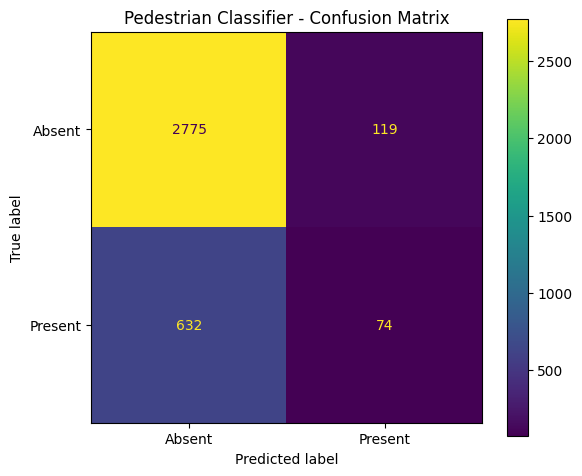

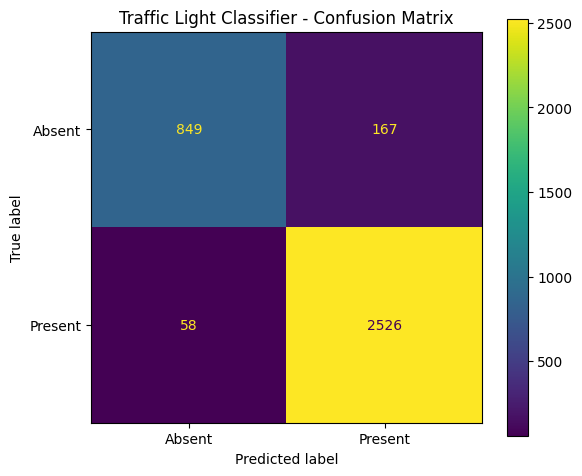

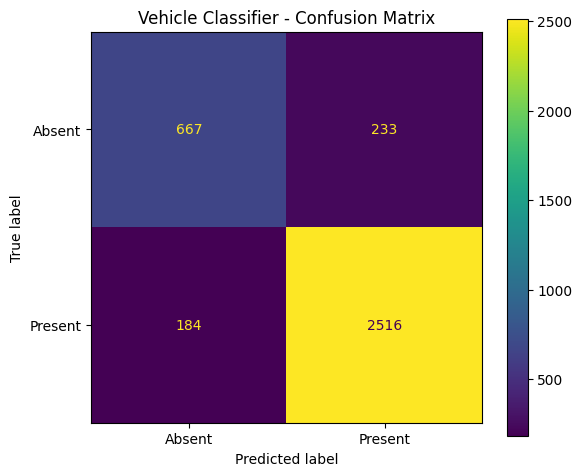

In [48]:
# ============================================================
# Cell 47: Confusion matrices
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay


for model_name, results in test_results.items():

    cm = results["confusion_matrix"]

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Absent",
            "Present"
        ]
    )

    display_cm.plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(
        f"{model_name} Classifier - Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()

In [49]:
# ============================================================
# Cell 48: Exercise 3.6 final analysis
# ============================================================

print("=" * 80)
print("EXERCISE 3.6 - TEST SET EVALUATION")
print("=" * 80)

print("\nPERFORMANCE")
print("-" * 60)

for model_name, results in test_results.items():

    print(f"\n{model_name}")
    print(
        f"  Accuracy  : "
        f"{results['accuracy'] * 100:.2f}%"
    )
    print(
        f"  Precision : "
        f"{results['precision'] * 100:.2f}%"
    )
    print(
        f"  Recall    : "
        f"{results['recall'] * 100:.2f}%"
    )
    print(
        f"  F1 Score  : "
        f"{results['f1'] * 100:.2f}%"
    )


# Determine worst model according to F1
worst_f1_model = min(
    test_results,
    key=lambda name: test_results[name]["f1"]
)

# Determine worst model according to recall
worst_recall_model = min(
    test_results,
    key=lambda name: test_results[name]["recall"]
)


print("\n" + "=" * 80)
print("WORST-PERFORMING MODEL")
print("=" * 80)

print(
    f"Lowest F1 score    : {worst_f1_model}"
)

print(
    f"Lowest recall      : {worst_recall_model}"
)

print(
    f"\nPedestrian recall  : "
    f"{test_results['Pedestrian']['recall'] * 100:.2f}%"
)

print(
    f"Traffic-light recall: "
    f"{test_results['Traffic Light']['recall'] * 100:.2f}%"
)

print(
    f"Vehicle recall     : "
    f"{test_results['Vehicle']['recall'] * 100:.2f}%"
)

print("\nExercise 3.6 completed.")

EXERCISE 3.6 - TEST SET EVALUATION

PERFORMANCE
------------------------------------------------------------

Pedestrian
  Accuracy  : 79.14%
  Precision : 38.34%
  Recall    : 10.48%
  F1 Score  : 16.46%

Traffic Light
  Accuracy  : 93.75%
  Precision : 93.80%
  Recall    : 97.76%
  F1 Score  : 95.74%

Vehicle
  Accuracy  : 88.42%
  Precision : 91.52%
  Recall    : 93.19%
  F1 Score  : 92.35%

WORST-PERFORMING MODEL
Lowest F1 score    : Pedestrian
Lowest recall      : Pedestrian

Pedestrian recall  : 10.48%
Traffic-light recall: 97.76%
Vehicle recall     : 93.19%

Exercise 3.6 completed.
